In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical, MultivariateNormal
from gymnasium.spaces import Discrete
from tqdm import tqdm

## PPO — Proximal Policy Optimization (Schulman et al., 2017)

Algorithm 1 from the paper, in plain words:

```
for iteration = 1, 2, ... do
    for actor = 1, ..., N (in parallel):
        run π_θ_old in env for T timesteps     # collect (s, a, r, V, done, log π_old)
        compute advantages Â_1, ..., Â_T       # via GAE
    optimize L(θ) wrt θ, K epochs, minibatch size M ≤ N·T
    θ_old ← θ
```

**Symbols used in this notebook:**

| Symbol     | Meaning                                                        | Variable  |
|------------|----------------------------------------------------------------|-----------|
| `T`        | timesteps each actor collects per iteration                    | `T`       |
| `N`        | number of parallel actors (vector env)                         | `N`       |
| `K`        | epochs of SGD over the rollout per iteration                   | `K`       |
| `M`        | minibatch size, `M ≤ N·T`                                      | `batch_size` |
| `γ`        | discount                                                       | `gamma`   |
| `λ`        | GAE smoothing                                                  | `lam`     |
| `ε`        | clip range in `L^CLIP`                                         | `clip_eps`|
| `c₁, c₂`   | value-loss and entropy-bonus weights                           | `c1, c2`  |

**Loss (Eq. 7 + Eq. 9 of the paper):**

$$
r_t(\theta) = \frac{\pi_\theta(a_t\mid s_t)}{\pi_{\theta_{\text{old}}}(a_t\mid s_t)},\quad
L^{\text{CLIP}} = \mathbb{E}_t\big[\min\big(r_t \hat A_t,\ \text{clip}(r_t, 1-\varepsilon, 1+\varepsilon)\hat A_t\big)\big]
$$

$$
L(\theta) = L^{\text{CLIP}}(\theta) - c_1\, L^{\text{VF}}(\theta) + c_2\, S[\pi_\theta]
$$

**GAE (Eq. 11–12):**

$$
\delta_t = r_t + \gamma V(s_{t+1})(1-\text{done}_t) - V(s_t),\quad
\hat A_t = \delta_t + \gamma\lambda(1-\text{done}_t)\hat A_{t+1}
$$

### 1. The MLP

A plain feed-forward network. We instantiate it twice:
- **Actor:** outputs `dim_A` numbers — logits for discrete actions, means for continuous actions.
- **Critic:** outputs a single scalar — the value `V(s)`.

Actor and critic are **separate networks** (paper §6.1).

In [8]:
class Network(nn.Module):
    def __init__(self, arch):
        super().__init__()
        self.arch = arch
        if len(self.arch) < 2:
            raise ValueError("Layer size cannot be smaller than 2")

        layers = []
        for in_features, out_features in zip(self.arch[:-1], self.arch[1:]):
            layers.append(nn.Linear(in_features, out_features))
            if out_features != self.arch[-1]:
                layers.append(nn.ReLU())

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

### 2. RolloutBuffer + GAE

PPO is **on-policy** — every gradient step uses data sampled from `π_θ_old`, then we discard it. The buffer is shaped `(T, N, …)` and holds one iteration's worth of transitions.

After collection we run the **GAE backward recursion** (Eq. 11–12) once to fill `advantages` and `returns`. The update step then iterates `K` epochs, each shuffling all `T·N` samples into minibatches of size `M`.

> Implementation note: the value target is `V_targ = Â + V_old`. This matches the paper's §5 description and is what every reference PPO implementation uses.

In [9]:
class RolloutBuffer(object):

    def __init__(self, T, N, dim_S, dim_A, discrete, device):
        self.T, self.N = T, N
        self.discrete = discrete
        self.device = device

        self.states     = torch.zeros((T, N, dim_S), device=device)
        self.actions    = torch.zeros((T, N), dtype=torch.long, device=device) if discrete \
                          else torch.zeros((T, N, dim_A), device=device)
        self.logprobs   = torch.zeros((T, N), device=device)   # log π_θ_old(a_t | s_t)
        self.rewards    = torch.zeros((T, N), device=device)
        self.values     = torch.zeros((T, N), device=device)   # V(s_t)
        self.dones      = torch.zeros((T, N), device=device)
        self.advantages = torch.zeros((T, N), device=device)
        self.returns    = torch.zeros((T, N), device=device)

    def store(self, t, state, action, logprob, reward, value, done):
        self.states[t]   = state
        self.actions[t]  = action
        self.logprobs[t] = logprob
        self.rewards[t]  = reward
        self.values[t]   = value
        self.dones[t]    = done

    def compute_gae(self, last_value, gamma, lam):
        # Â_t = δ_t + (γλ)(1 - done_t) Â_{t+1},   Â_T = 0
        adv = torch.zeros(self.N, device=self.device)
        for t in reversed(range(self.T)):
            next_value = last_value if t == self.T - 1 else self.values[t + 1]
            mask = 1.0 - self.dones[t]
            delta = self.rewards[t] + gamma * next_value * mask - self.values[t]
            adv = delta + gamma * lam * mask * adv
            self.advantages[t] = adv
        self.returns = self.advantages + self.values

    def iter_minibatches(self, batch_size):
        # flatten (T, N, ...) -> (T*N, ...) and shuffle
        flat_states  = self.states.reshape(-1, self.states.shape[-1])
        flat_actions = self.actions.reshape(-1) if self.discrete \
                       else self.actions.reshape(-1, self.actions.shape[-1])
        flat_lp      = self.logprobs.reshape(-1)
        flat_adv     = self.advantages.reshape(-1)
        flat_ret     = self.returns.reshape(-1)

        N_total = flat_states.shape[0]
        idxs = torch.randperm(N_total, device=self.device)
        for start in range(0, N_total, batch_size):
            mb = idxs[start:start + batch_size]
            yield flat_states[mb], flat_actions[mb], flat_lp[mb], flat_adv[mb], flat_ret[mb]

### 3. RunPPO — Algorithm 1

The class is split into four methods that map 1:1 to the paper's Algorithm 1:

| Method            | Paper line                                                       |
|-------------------|------------------------------------------------------------------|
| `_policy(s)`      | builds `π_θ(·|s)` — `Categorical` (discrete) or `MultivariateNormal` (continuous) |
| `_collect_rollout`| "run π_θ_old in env for T timesteps" + "compute advantages"      |
| `_update`         | "optimize L wrt θ, with K epochs and minibatch size M"           |
| `learn`           | the outer iteration loop                                          |

For continuous actions the policy is `N(μ_θ(s), σ²)` with a **state-independent** `log σ` learned as a free parameter — the paper's choice in §6.1.

Two engineering details that aren't in the paper but are in **every** reference implementation, so we include them:
- **Per-minibatch advantage normalization** (zero-mean, unit-std).
- **Global gradient norm clipping** at 0.5.

In [10]:
class RunPPO(object):
    def __init__(self,
                 env,                        # gymnasium.vector env with N parallel copies
                 T=128,                      # timesteps per actor per iteration
                 K=10,                       # update epochs per iteration
                 batch_size=64,              # minibatch size M, must divide T*N (or last batch is shorter)
                 lr=3e-4,
                 gamma=0.99,
                 lam=0.95,                   # GAE λ
                 clip_eps=0.2,               # ε in L^CLIP
                 c1=0.5,                     # value-loss coefficient
                 c2=0.01,                    # entropy bonus coefficient
                 max_grad_norm=0.5,
                 arch=None,                  # hidden layers, e.g. [64, 64]
                 action_std_init=0.6):       # initial σ for continuous actions

        self.env = env
        self.N = env.num_envs
        self.T = T
        self.K = K
        self.batch_size = batch_size
        self.gamma = gamma
        self.lam = lam
        self.clip_eps = clip_eps
        self.c1 = c1
        self.c2 = c2
        self.max_grad_norm = max_grad_norm

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # --- spaces -----------------------------------------------------------
        self.dim_S = env.single_observation_space.shape[0]
        self.discrete = isinstance(env.single_action_space, Discrete)
        self.dim_A = env.single_action_space.n if self.discrete \
                     else env.single_action_space.shape[0]

        # --- networks ---------------------------------------------------------
        hidden = arch if arch is not None else [64, 64]
        self.actor  = Network([self.dim_S, *hidden, self.dim_A]).to(self.device)
        self.critic = Network([self.dim_S, *hidden, 1]).to(self.device)

        params = list(self.actor.parameters()) + list(self.critic.parameters())
        if not self.discrete:
            # state-independent log σ, learned (paper §6.1)
            self.log_std = nn.Parameter(
                torch.full((self.dim_A,), float(np.log(action_std_init)), device=self.device)
            )
            params.append(self.log_std)

        self.optimizer = optim.Adam(params, lr=lr)
        self.buffer = RolloutBuffer(T, self.N, self.dim_S, self.dim_A, self.discrete, self.device)

    # ---------------------------------------------------------------------------
    # π_θ(·|s) as a torch.distributions object — used for sampling AND log-prob
    # ---------------------------------------------------------------------------
    def _policy(self, state):
        out = self.actor(state)
        if self.discrete:
            return Categorical(logits=out)
        std = self.log_std.exp().expand_as(out)
        cov = torch.diag_embed(std ** 2)
        return MultivariateNormal(out, cov)

    @torch.no_grad()
    def _act(self, state):
        dist = self._policy(state)
        action = dist.sample()
        logprob = dist.log_prob(action)
        value = self.critic(state).squeeze(-1)
        return action, logprob, value

    # ---------------------------------------------------------------------------
    # "Run π_θ_old in env for T timesteps; compute advantages" (Alg. 1, lines 3-5)
    # ---------------------------------------------------------------------------
    def _collect_rollout(self, state, ep_rewards, running_reward):
        for t in range(self.T):
            state_t = torch.as_tensor(state, dtype=torch.float32, device=self.device)
            action, logprob, value = self._act(state_t)

            action_np = action.cpu().numpy()
            next_state, reward, terminated, truncated, _ = self.env.step(action_np)
            done = np.logical_or(terminated, truncated)

            self.buffer.store(
                t,
                state_t,
                action,
                logprob,
                torch.as_tensor(reward, dtype=torch.float32, device=self.device),
                value,
                torch.as_tensor(done, dtype=torch.float32, device=self.device),
            )

            running_reward += reward
            for i, d in enumerate(done):
                if d:
                    ep_rewards.append(float(running_reward[i]))
                    running_reward[i] = 0.0

            state = next_state

        # bootstrap V(s_{T}) for the GAE recursion
        with torch.no_grad():
            last_value = self.critic(
                torch.as_tensor(state, dtype=torch.float32, device=self.device)
            ).squeeze(-1)
        self.buffer.compute_gae(last_value, self.gamma, self.lam)
        return state

    # ---------------------------------------------------------------------------
    # "Optimize L wrt θ, with K epochs and minibatch size M" (Alg. 1, line 6)
    # L = L^CLIP - c1 * L^VF + c2 * S
    # ---------------------------------------------------------------------------
    def _update(self):
        for _ in range(self.K):
            for states, actions, old_logprobs, advantages, returns in self.buffer.iter_minibatches(self.batch_size):
                # advantage normalization (engineering detail — see markdown above)
                advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

                dist = self._policy(states)
                new_logprobs = dist.log_prob(actions)
                entropy = dist.entropy().mean()

                # r_t(θ) = exp(log π_θ(a) − log π_θ_old(a))
                ratio = torch.exp(new_logprobs - old_logprobs)

                # L^CLIP — Eq. 7
                surr1 = ratio * advantages
                surr2 = torch.clamp(ratio, 1.0 - self.clip_eps, 1.0 + self.clip_eps) * advantages
                policy_loss = -torch.min(surr1, surr2).mean()

                # L^VF — squared error of value head against returns
                values = self.critic(states).squeeze(-1)
                value_loss = (values - returns).pow(2).mean()

                # combined loss — Eq. 9 (we minimize, hence the sign on entropy)
                loss = policy_loss + self.c1 * value_loss - self.c2 * entropy

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.optimizer.param_groups[0]["params"], self.max_grad_norm)
                self.optimizer.step()

    # ---------------------------------------------------------------------------
    # Outer loop (Alg. 1, line 1 — "for iteration = 1, 2, ...")
    # ---------------------------------------------------------------------------
    def learn(self, total_iterations):
        state, _ = self.env.reset()
        running_reward = np.zeros(self.N, dtype=np.float32)
        ep_rewards = []

        for _ in tqdm(range(total_iterations)):
            state = self._collect_rollout(state, ep_rewards, running_reward)
            self._update()

        return ep_rewards

### 4. Train on CartPole-v1 (discrete actions, 3 seeds)

`gym.vector.SyncVectorEnv` gives us the **N parallel actors** from Algorithm 1. With `T=128, N=4` we collect `512` transitions per iteration; with `K=4, batch_size=64` that's `8 minibatches × 4 epochs = 32` SGD steps per iteration.

We run 3 seeds, smooth each with a moving average, then plot mean ± 1 std with `fill_between`. CartPole episodes vary in length, so we truncate every run to the shortest seed's episode count before averaging.

100%|██████████| 200/200 [00:10<00:00, 18.70it/s]


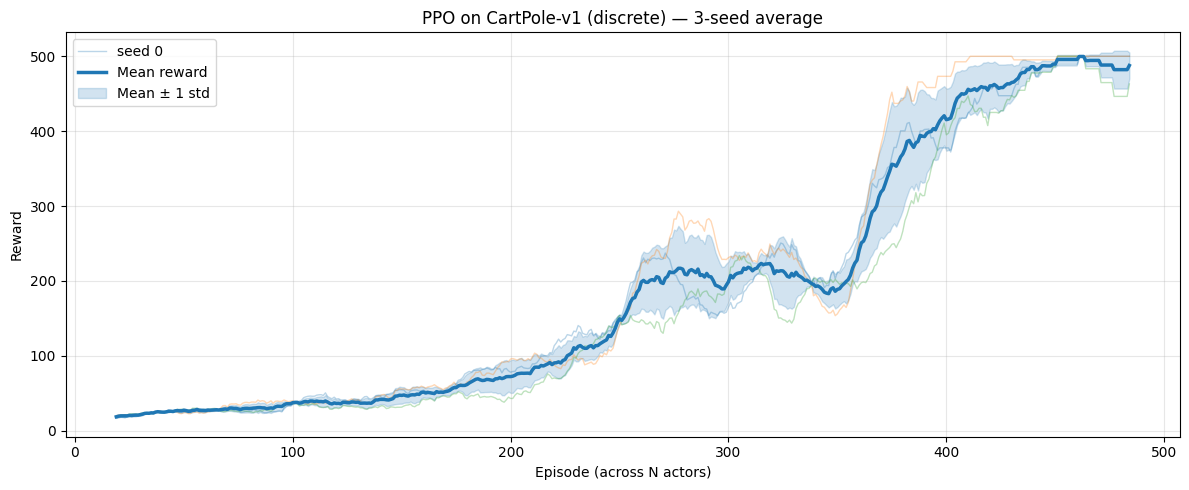

Final 20-episode averages per seed: [500.0, 500.0, 463.05]


In [11]:
import random
import gymnasium as gym
import matplotlib.pyplot as plt

SEEDS = [0, 16, 25]
N_ACTORS = 4
TOTAL_ITERATIONS = 200
WINDOW = 20

cartpole_runs = []

for seed in SEEDS:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    env = gym.vector.SyncVectorEnv(
        [lambda: gym.make("CartPole-v1") for _ in range(N_ACTORS)]
    )
    env.reset(seed=seed)
    env.action_space.seed(seed)

    agent = RunPPO(
        env=env,
        T=128,
        K=4,
        batch_size=64,
        lr=3e-4,
        gamma=0.99,
        lam=0.95,
        clip_eps=0.2,
        c1=0.5,
        c2=0.01,
        arch=[64, 64],
    )
    ep_rewards = agent.learn(total_iterations=TOTAL_ITERATIONS)
    cartpole_runs.append(ep_rewards)
    env.close()

# Truncate every run to the shortest one so they line up.
min_len = min(len(r) for r in cartpole_runs)
trimmed = np.array([r[:min_len] for r in cartpole_runs])

def moving_average(values, window):
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

smoothed = np.array([moving_average(run, WINDOW) for run in trimmed])
episodes = np.arange(WINDOW - 1, min_len)

mean_r = smoothed.mean(axis=0)
std_r  = smoothed.std(axis=0)

plt.figure(figsize=(12, 5))
for i, run in enumerate(smoothed):
    plt.plot(episodes, run, alpha=0.3, linewidth=1,
             label=f"seed {SEEDS[i]}" if i == 0 else None)
plt.plot(episodes, mean_r, color="tab:blue", linewidth=2.5, label="Mean reward")
plt.fill_between(episodes, mean_r - std_r, mean_r + std_r,
                 color="tab:blue", alpha=0.2, label="Mean ± 1 std")
plt.xlabel("Episode (across N actors)")
plt.ylabel("Reward")
plt.title("PPO on CartPole-v1 (discrete) — 3-seed average")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Final 20-episode averages per seed:",
      [round(np.mean(run[-20:]), 2) for run in trimmed])

### 5. Train on Pendulum-v1 (continuous actions, 3 seeds)

This exercises the **continuous branch** of `_policy`: the actor outputs the mean of a `MultivariateNormal`, with a learned state-independent `log σ`. Pendulum has 200-step fixed-length episodes, so the per-seed episode counts are identical and we don't need to truncate.

We use larger `T` and smaller `c2` (less entropy bonus) which is conventional for continuous control. Reward is negative — improvement looks like a curve rising from ~−1500 toward ~−200.

100%|██████████| 120/120 [01:03<00:00,  1.90it/s]


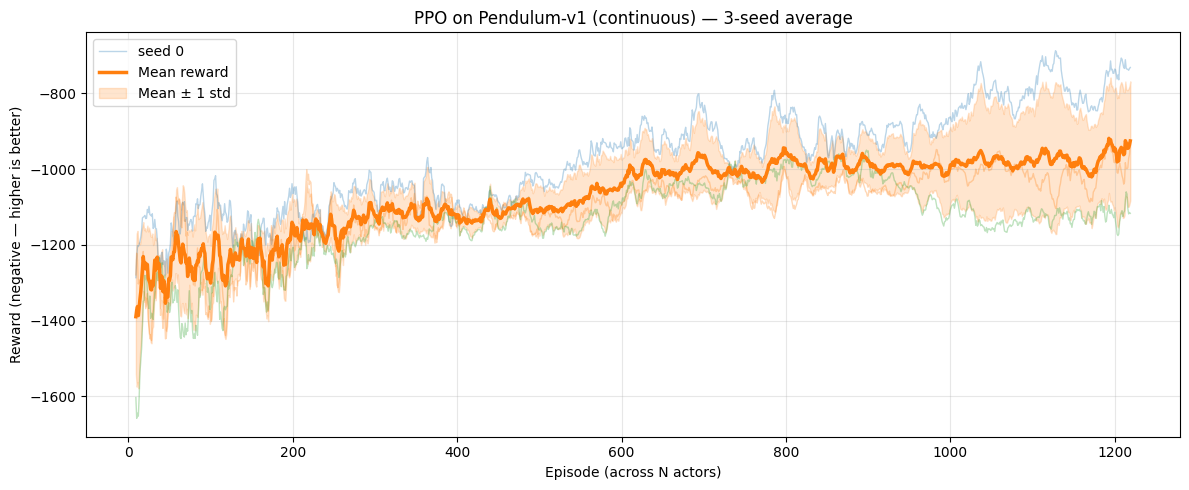

Final 10-episode averages per seed: [-731.63, -928.28, -1116.77]


In [12]:
SEEDS = [0, 16, 25]
N_ACTORS = 4
TOTAL_ITERATIONS = 120
WINDOW = 10

pendulum_runs = []

for seed in SEEDS:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    env = gym.vector.SyncVectorEnv(
        [lambda: gym.make("Pendulum-v1") for _ in range(N_ACTORS)]
    )
    env.reset(seed=seed)
    env.action_space.seed(seed)

    agent = RunPPO(
        env=env,
        T=512,
        K=10,
        batch_size=64,
        lr=3e-4,
        gamma=0.99,
        lam=0.95,
        clip_eps=0.2,
        c1=0.5,
        c2=0.0,                # entropy bonus often dropped for continuous control
        arch=[64, 64],
        action_std_init=0.6,
    )
    ep_rewards = agent.learn(total_iterations=TOTAL_ITERATIONS)
    pendulum_runs.append(ep_rewards)
    env.close()

# Pendulum episodes are fixed-length, but small variance is possible — truncate to be safe.
min_len = min(len(r) for r in pendulum_runs)
trimmed = np.array([r[:min_len] for r in pendulum_runs])

smoothed = np.array([moving_average(run, WINDOW) for run in trimmed])
episodes = np.arange(WINDOW - 1, min_len)

mean_r = smoothed.mean(axis=0)
std_r  = smoothed.std(axis=0)

plt.figure(figsize=(12, 5))
for i, run in enumerate(smoothed):
    plt.plot(episodes, run, alpha=0.3, linewidth=1,
             label=f"seed {SEEDS[i]}" if i == 0 else None)
plt.plot(episodes, mean_r, color="tab:orange", linewidth=2.5, label="Mean reward")
plt.fill_between(episodes, mean_r - std_r, mean_r + std_r,
                 color="tab:orange", alpha=0.2, label="Mean ± 1 std")
plt.xlabel("Episode (across N actors)")
plt.ylabel("Reward (negative — higher is better)")
plt.title("PPO on Pendulum-v1 (continuous) — 3-seed average")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Final 10-episode averages per seed:",
      [round(np.mean(run[-10:]), 2) for run in trimmed])